# Model Validation and Scorecard Analysis

This notebook validates the Probability of Default model using standard credit risk model evaluation techniques.

The objective is to evaluate whether the model can separate high-risk borrowers from low-risk borrowers and interpret which variables contribute most to default risk.

The notebook covers:

1. ROC-AUC
2. Gini Coefficient
3. KS Statistic
4. Risk Decile Analysis
5. Model Coefficients
6. Threshold Analysis
7. Scorecard-style Risk Ranking

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [3]:
df = pd.read_csv("../data/raw/cs-training.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
target = "SeriousDlqin2yrs"

X = df.drop(columns=[target])
y = df[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (150000, 10)
Target data shape: (150000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120000, 10)
Testing data: (30000, 10)


In [8]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [10]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [11]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

y_pred_proba[:10]

array([0.27555205, 0.24734206, 0.29742773, 0.31471829, 0.28096643,
       0.19210911, 0.29640917, 1.        , 0.51851863, 0.56976763])

In [12]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * roc_auc - 1

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")

ROC-AUC Score: 0.8021
Gini Coefficient: 0.6043


## ROC-AUC and Gini Interpretation

ROC-AUC measures how well the model separates defaulters from non-defaulters.

A ROC-AUC of 0.50 means the model is no better than random guessing. A higher ROC-AUC indicates better separation power.

The Gini coefficient is derived from ROC-AUC using:

Gini = 2 × ROC-AUC - 1

In credit risk modelling, Gini is commonly used to evaluate discriminatory power.

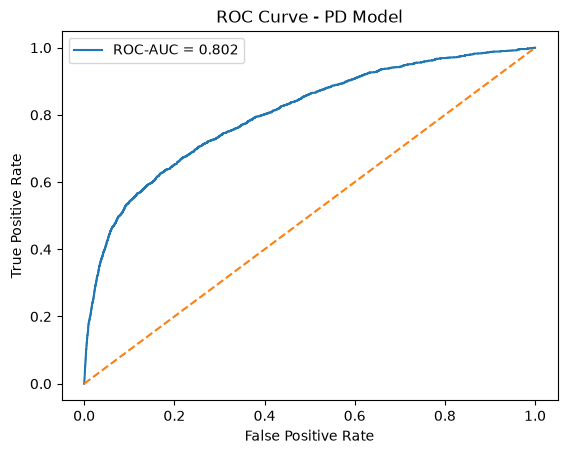

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PD Model")
plt.legend()
plt.show()

In [16]:
validation_df = pd.DataFrame({
    "Actual_Default": y_test.values,
    "Predicted_PD": y_pred_proba
})

validation_df = validation_df.sort_values("Predicted_PD", ascending=False)

validation_df["Cumulative_Defaults"] = validation_df["Actual_Default"].cumsum()
validation_df["Cumulative_Non_Defaults"] = (1 - validation_df["Actual_Default"]).cumsum()

total_defaults = validation_df["Actual_Default"].sum()
total_non_defaults = (1 - validation_df["Actual_Default"]).sum()

validation_df["Cumulative_Default_Rate"] = validation_df["Cumulative_Defaults"] / total_defaults
validation_df["Cumulative_Non_Default_Rate"] = validation_df["Cumulative_Non_Defaults"] / total_non_defaults

validation_df["KS"] = abs(
    validation_df["Cumulative_Default_Rate"] -
    validation_df["Cumulative_Non_Default_Rate"]
)

ks_statistic = validation_df["KS"].max()

print(f"KS Statistic: {ks_statistic:.4f}")

KS Statistic: 0.4568


## KS Statistic Interpretation

The KS Statistic measures the maximum separation between the cumulative distribution of defaulters and non-defaulters.

A higher KS value means the model is better at separating risky borrowers from safer borrowers.

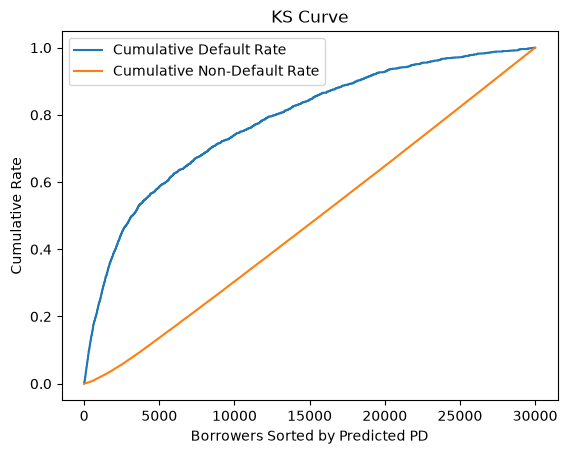

In [18]:
plt.plot(validation_df["Cumulative_Default_Rate"].values, label="Cumulative Default Rate")
plt.plot(validation_df["Cumulative_Non_Default_Rate"].values, label="Cumulative Non-Default Rate")

plt.title("KS Curve")
plt.xlabel("Borrowers Sorted by Predicted PD")
plt.ylabel("Cumulative Rate")
plt.legend()
plt.show()

In [20]:
validation_df["Risk_Decile"] = pd.qcut(
    validation_df["Predicted_PD"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_summary = validation_df.groupby("Risk_Decile").agg(
    Borrower_Count=("Actual_Default", "count"),
    Average_PD=("Predicted_PD", "mean"),
    Actual_Default_Rate=("Actual_Default", "mean")
).sort_values("Average_PD", ascending=False)

decile_summary

,Borrower_Count,Average_PD,Actual_Default_Rate
Risk_Decile,,,
9,3000,0.731411,0.326000
8,3000,0.551697,0.092333
7,3000,0.498763,0.060333
6,3000,0.456194,0.046667
5,3000,0.416072,0.039333
4,3000,0.377243,0.035333
3,3000,0.337634,0.028667
2,3000,0.300031,0.017667
1,3000,0.261885,0.012333


## Risk Decile Interpretation

Risk decile analysis checks whether borrowers with higher predicted PD actually show higher default rates.

A good credit risk model should show a clear pattern:

Highest-risk deciles → higher actual default rate  
Lowest-risk deciles → lower actual default rate

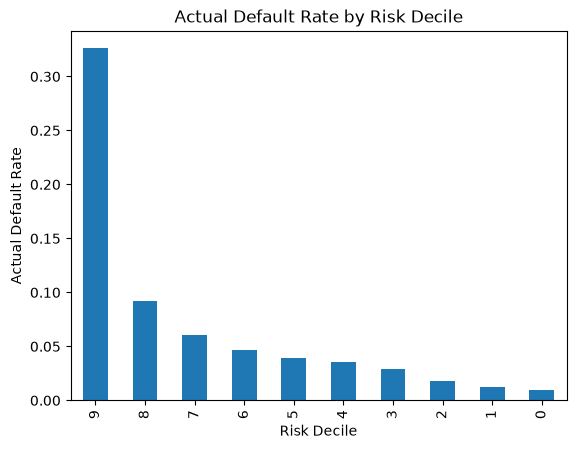

In [22]:
decile_summary["Actual_Default_Rate"].plot(kind="bar")

plt.title("Actual Default Rate by Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Actual Default Rate")
plt.show()

In [23]:
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficient_df["Abs_Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df = coefficient_df.sort_values("Abs_Coefficient", ascending=False)

coefficient_df

,Feature,Coefficient,Abs_Coefficient
2,NumberOfTime30-59DaysPastDueNotWorse,2.189262,2.189262
6,NumberOfTimes90DaysLate,2.118612,2.118612
1,age,-0.433961,0.433961
4,MonthlyIncome,-0.281504,0.281504
8,NumberOfTime60-89DaysPastDueNotWorse,0.193191,0.193191
3,DebtRatio,-0.097117,0.097117
7,NumberRealEstateLoansOrLines,0.086131,0.086131
9,NumberOfDependents,0.070102,0.070102
5,NumberOfOpenCreditLinesAndLoans,-0.015200,0.015200
0,RevolvingUtilizationOfUnsecuredLines,-0.001123,0.001123


## Model Coefficient Interpretation

In logistic regression, coefficients show how each variable affects the predicted probability of default.

A positive coefficient means the variable increases default risk.

A negative coefficient means the variable reduces default risk.

Because the features were scaled before modelling, the coefficients can be compared more fairly.

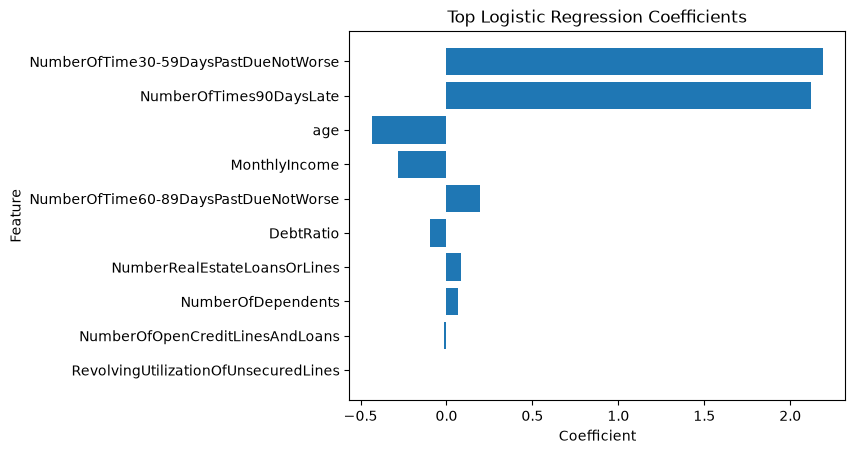

In [25]:
top_features = coefficient_df.head(10)

plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [27]:
thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds_to_test:
    predicted_class = (y_pred_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predicted_class),
        "Precision": precision_score(y_test, predicted_class, zero_division=0),
        "Recall": recall_score(y_test, predicted_class, zero_division=0),
        "F1_Score": f1_score(y_test, predicted_class, zero_division=0),
        "Predicted_Default_Rate": predicted_class.mean()
    })

threshold_summary = pd.DataFrame(threshold_results)

threshold_summary

,Threshold,Accuracy,Precision,Recall,F1_Score,Predicted_Default_Rate
0,0.1,0.067933,0.066907,1.000000,0.125422,0.998900
1,0.2,0.106967,0.069149,0.992020,0.129286,0.958800
2,0.3,0.311167,0.085149,0.955112,0.156358,0.749667
3,0.4,0.553333,0.114069,0.839900,0.200859,0.492100
4,0.5,0.776233,0.181634,0.669825,0.285775,0.246467


## Threshold Analysis Interpretation

The threshold determines when a borrower is classified as high risk.

A lower threshold catches more defaulters but may also flag many safe borrowers.

A higher threshold is stricter but may miss some risky borrowers.

In credit risk, the best threshold depends on the lender's risk appetite.

In [29]:
scorecard_df = coefficient_df.copy()

scorecard_df["Risk_Impact"] = np.where(
    scorecard_df["Coefficient"] > 0,
    "Increases Default Risk",
    "Reduces Default Risk"
)

scorecard_df["Importance_Rank"] = range(1, len(scorecard_df) + 1)

scorecard_df[["Importance_Rank", "Feature", "Coefficient", "Risk_Impact"]]

,Importance_Rank,Feature,Coefficient,Risk_Impact
2,1,NumberOfTime30-59DaysPastDueNotWorse,2.189262,Increases Default Risk
6,2,NumberOfTimes90DaysLate,2.118612,Increases Default Risk
1,3,age,-0.433961,Reduces Default Risk
4,4,MonthlyIncome,-0.281504,Reduces Default Risk
8,5,NumberOfTime60-89DaysPastDueNotWorse,0.193191,Increases Default Risk
3,6,DebtRatio,-0.097117,Reduces Default Risk
7,7,NumberRealEstateLoansOrLines,0.086131,Increases Default Risk
9,8,NumberOfDependents,0.070102,Increases Default Risk
5,9,NumberOfOpenCreditLinesAndLoans,-0.015200,Reduces Default Risk
0,10,RevolvingUtilizationOfUnsecuredLines,-0.001123,Reduces Default Risk


In [30]:
decile_summary.to_csv("../data/processed/risk_decile_summary.csv")
coefficient_df.to_csv("../data/processed/model_coefficients.csv", index=False)
threshold_summary.to_csv("../data/processed/threshold_analysis.csv", index=False)

## Final Model Validation Summary

The model validation notebook evaluates whether the Probability of Default model can separate high-risk borrowers from low-risk borrowers.

The key validation outputs are:

1. ROC-AUC Score
2. Gini Coefficient
3. KS Statistic
4. Risk Decile Analysis
5. Threshold Analysis
6. Model Coefficient Interpretation

The risk decile analysis is especially useful because it shows whether borrowers ranked as high risk by the model actually have higher observed default rates.

The scorecard-style ranking provides interpretability by showing which variables contribute most strongly to default risk.

This strengthens the project by moving it from a basic machine learning model to a more complete credit risk modelling framework.